In [1]:
from ultralytics import YOLO
# 1. Cargar un modelo pre-entrenado (YOLOv8 nano es rápido y ligero)
model = YOLO('yolo11n.pt')
# 2. Entrenar el modelo
results = model.train(
data='dataset/data.yaml',
epochs=20, # Número de vueltas al dataset
imgsz=640, # Tamaño de la imagen
plots=True,
device=0
)

New https://pypi.org/project/ultralytics/8.4.11 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.235 🚀 Python-3.13.5 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12044MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None,

Resultados en: runs/detect/train

Visualizaciones

Curvas de entrenamiento:


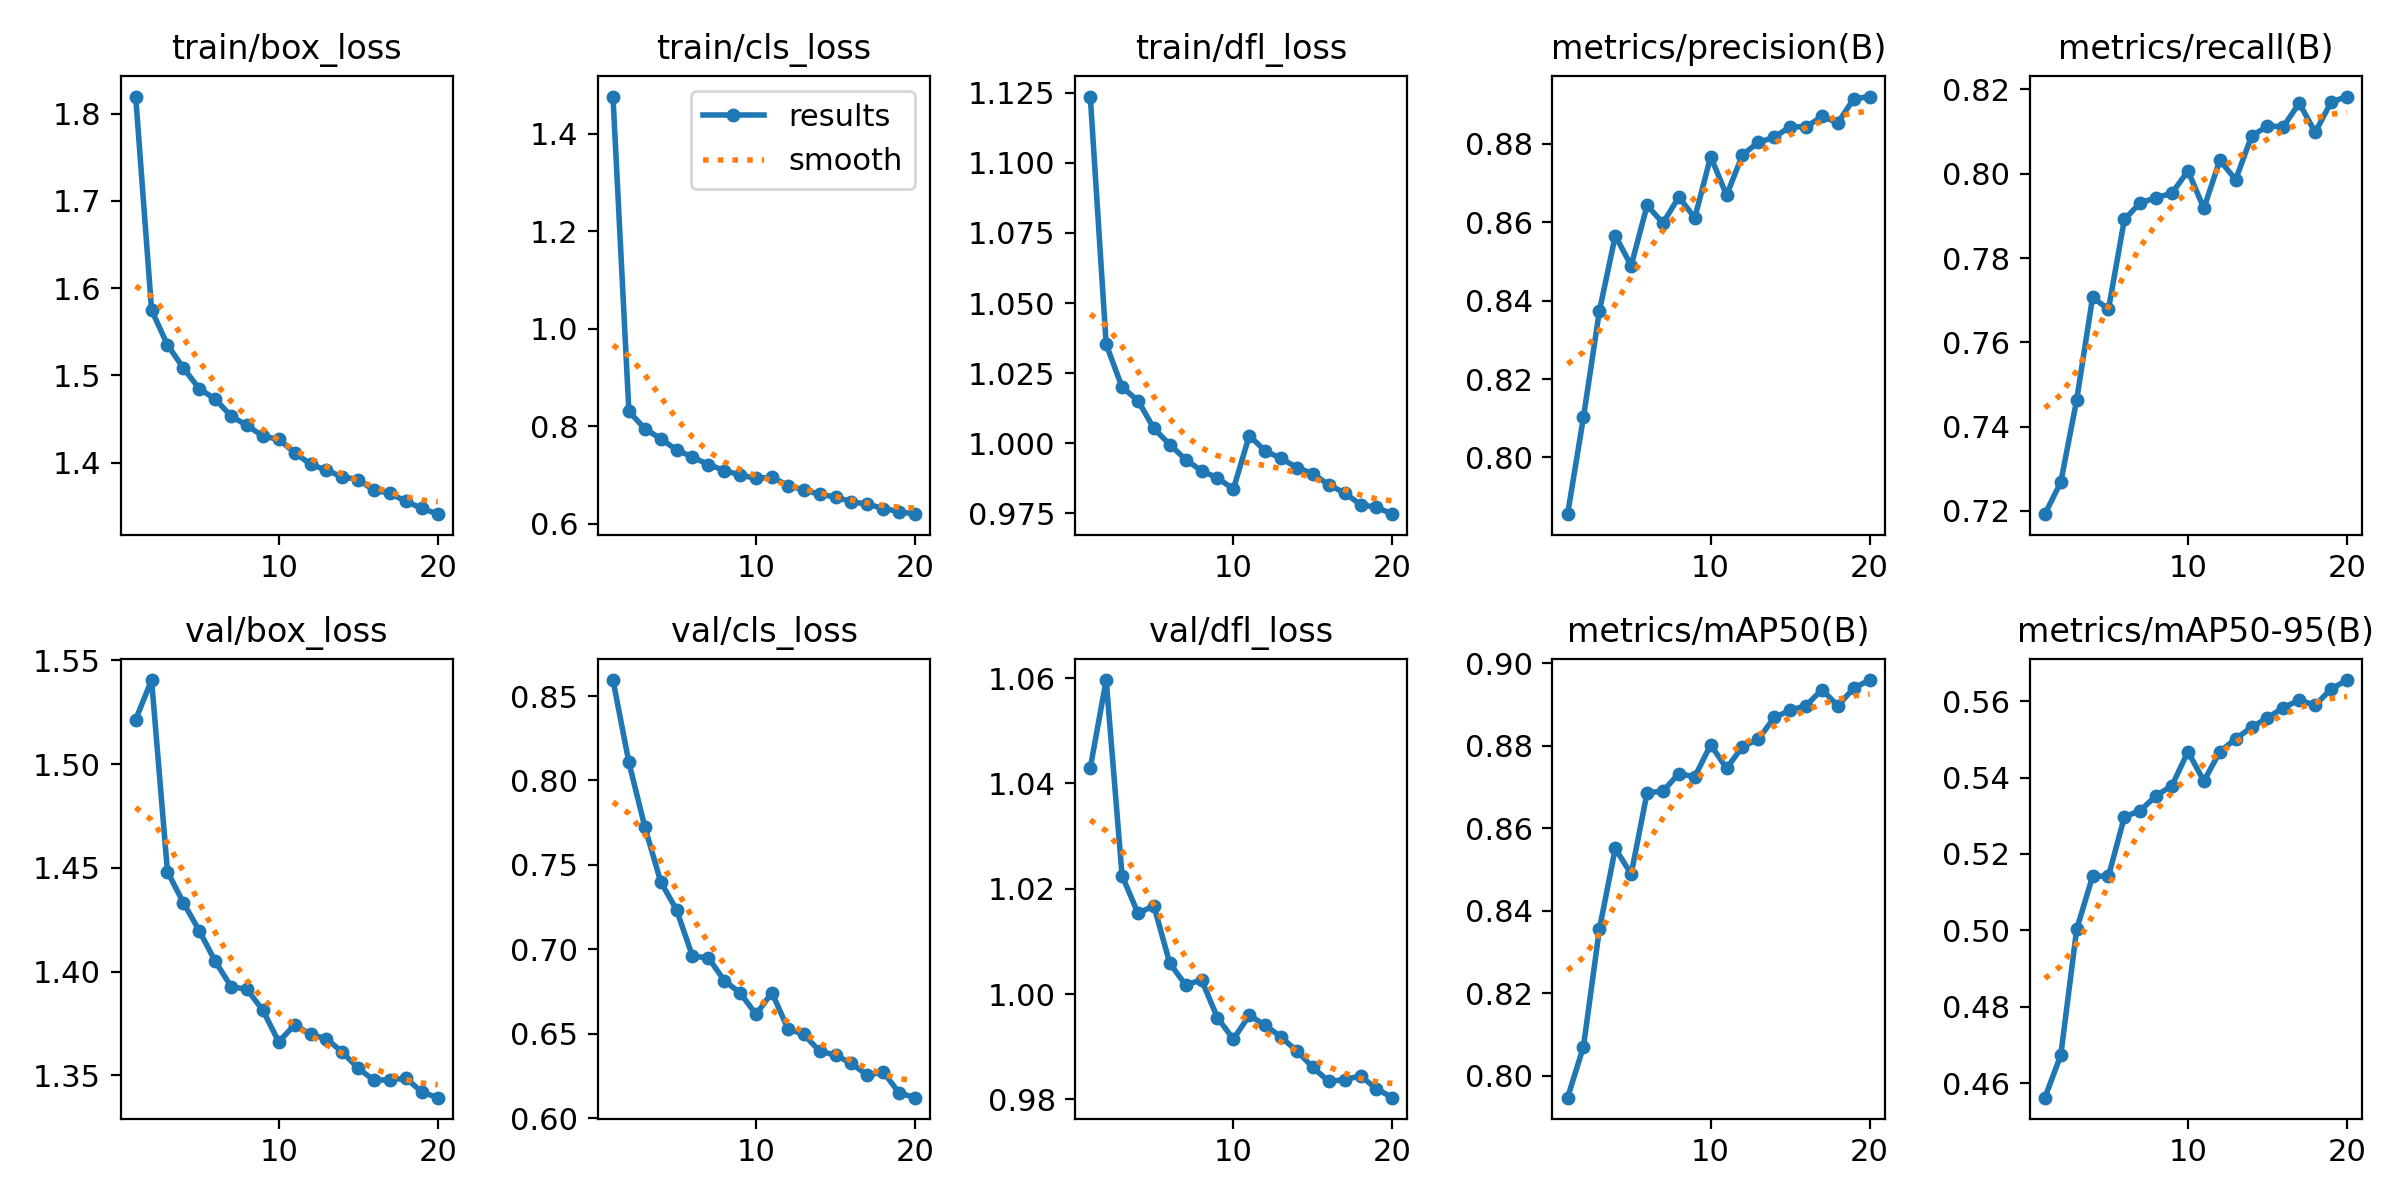


Predicciones de validación:


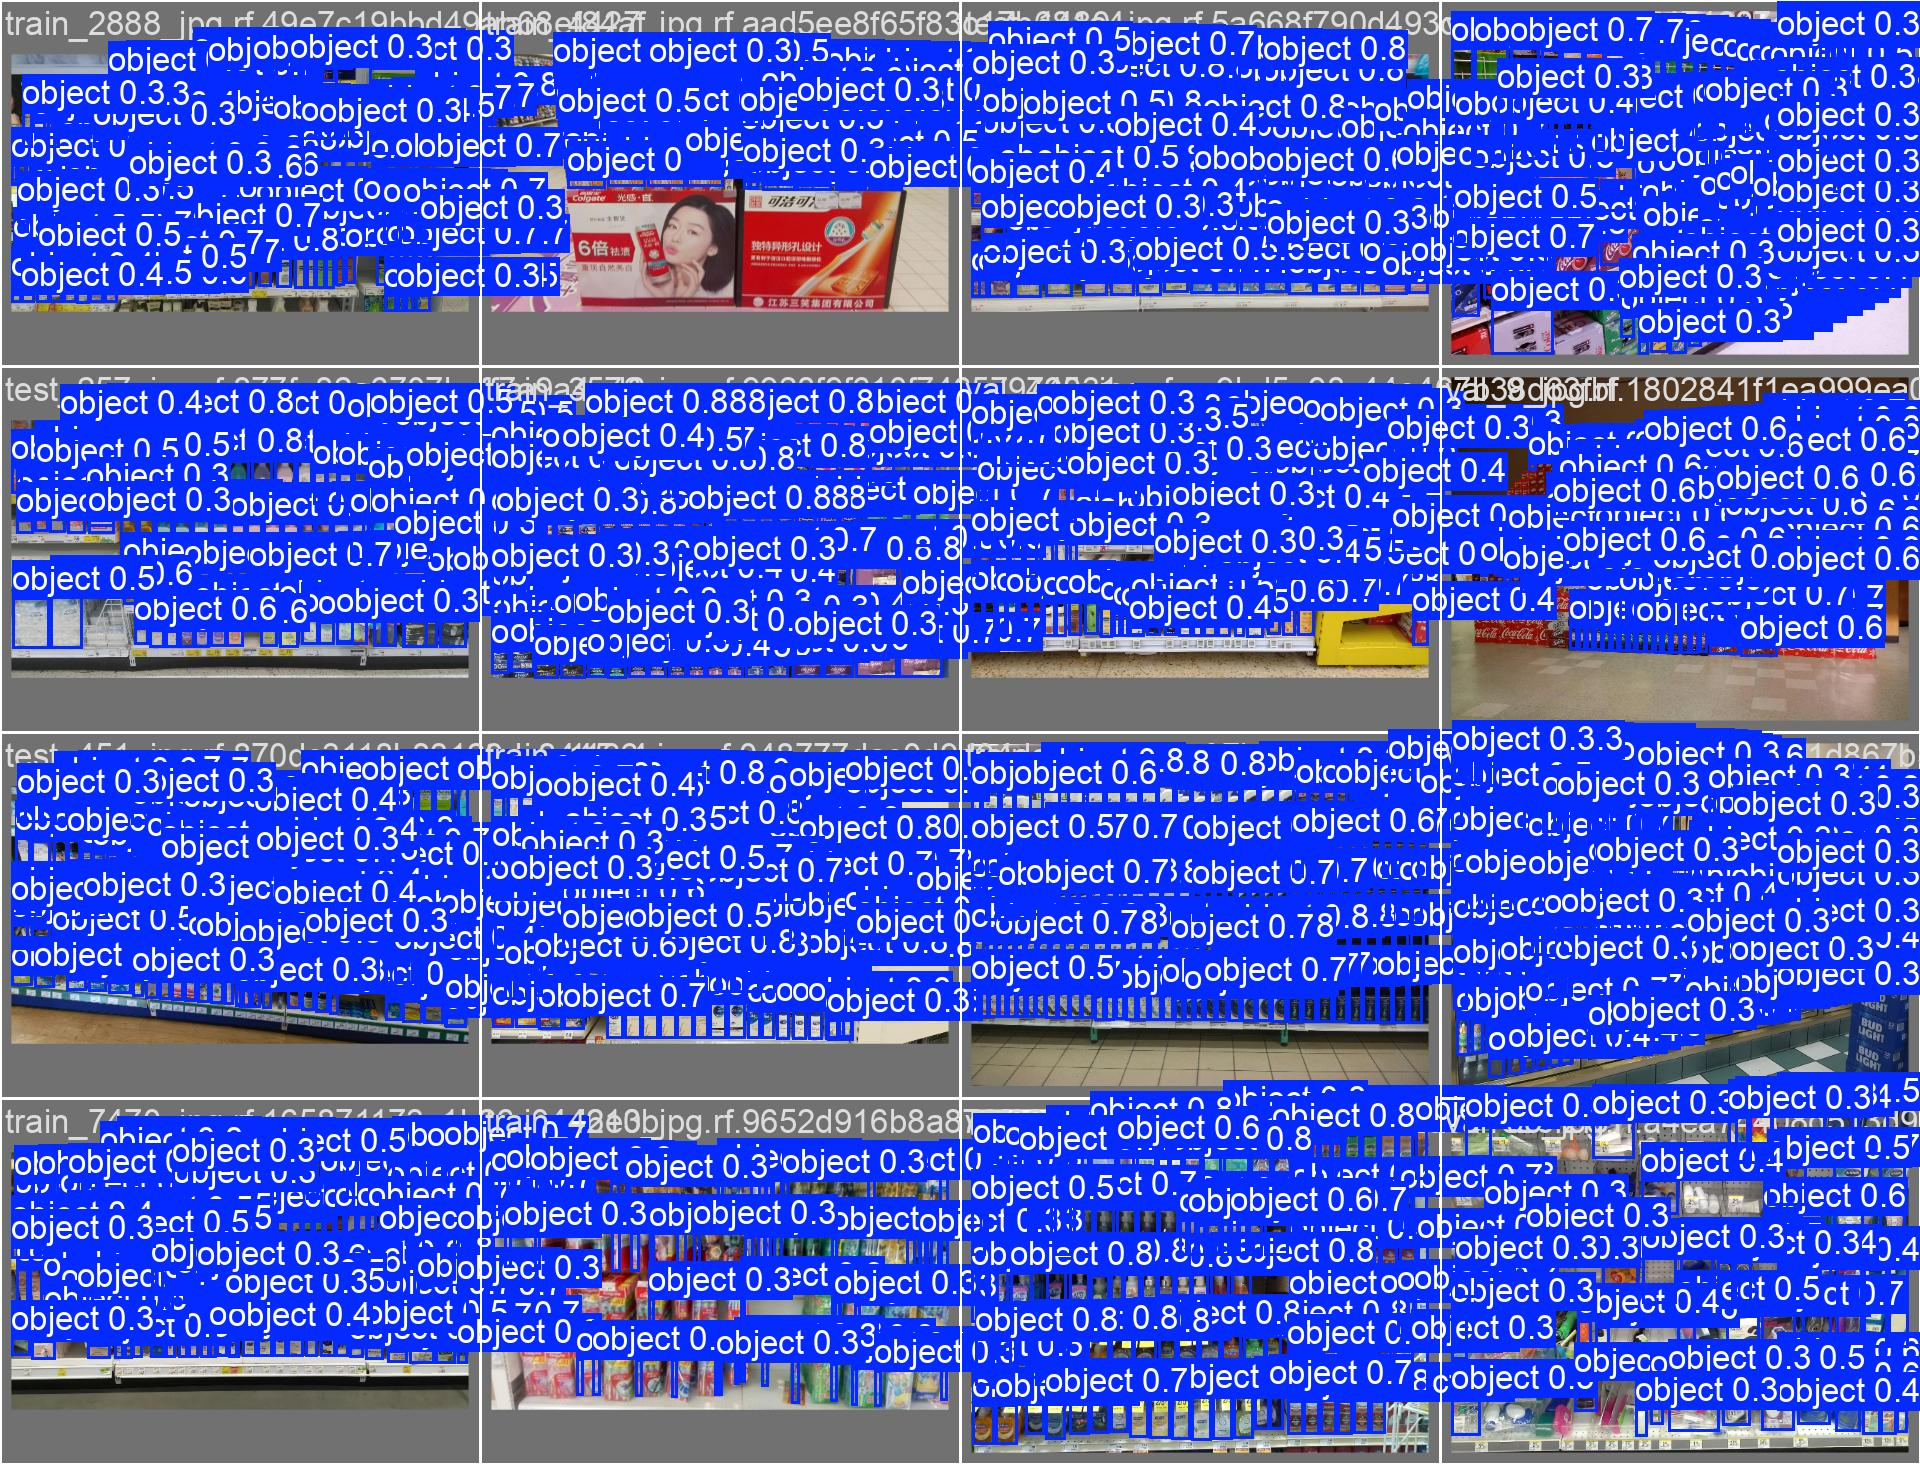


Ground Truth:


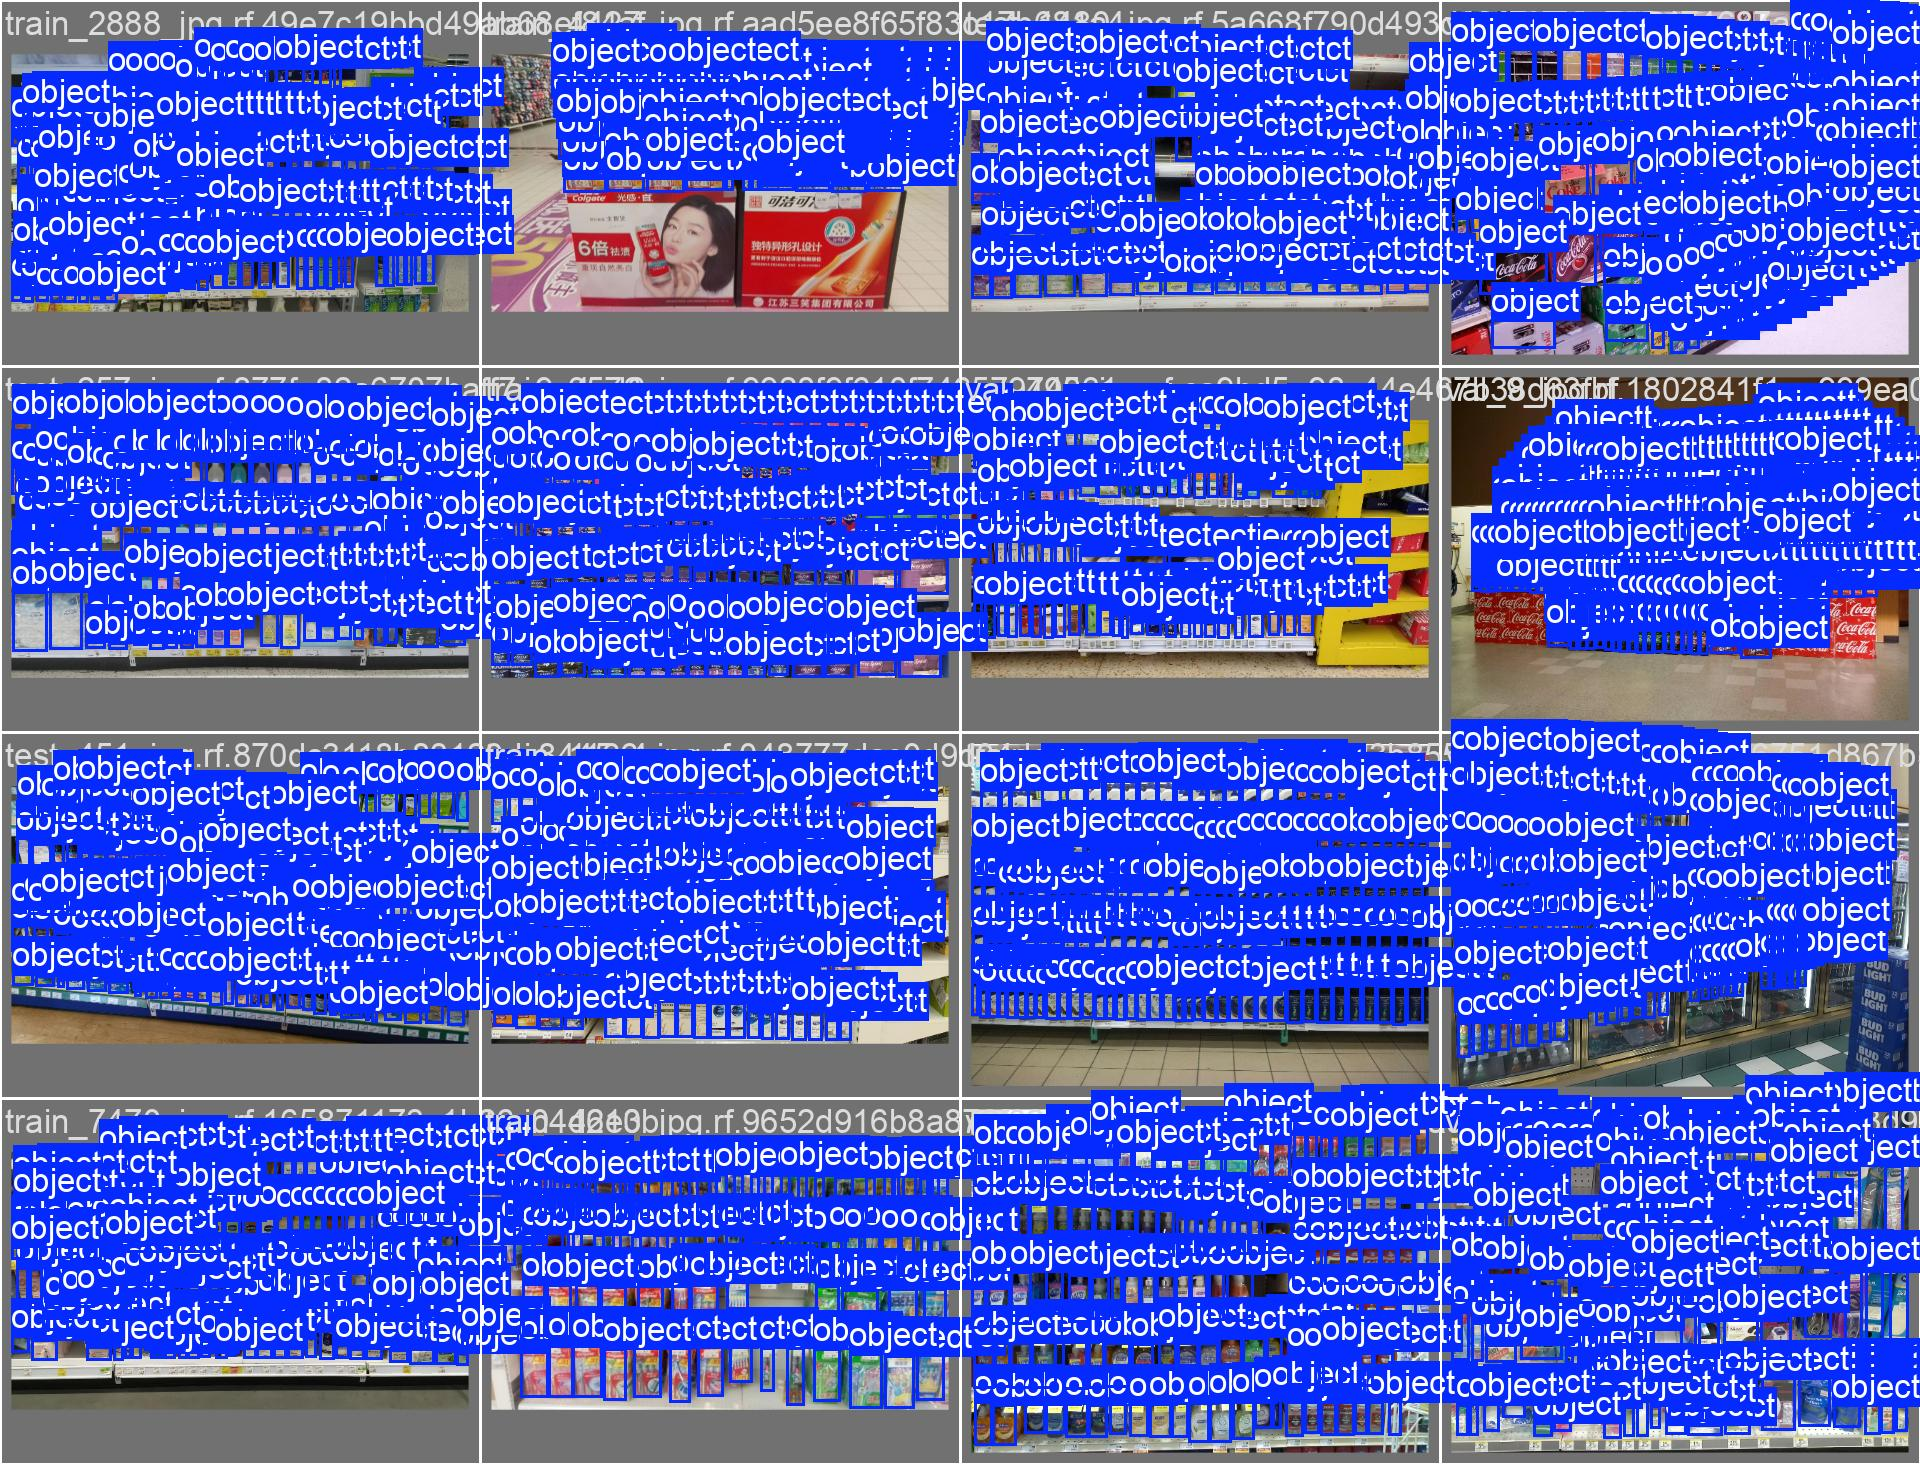


Matriz de confusión:


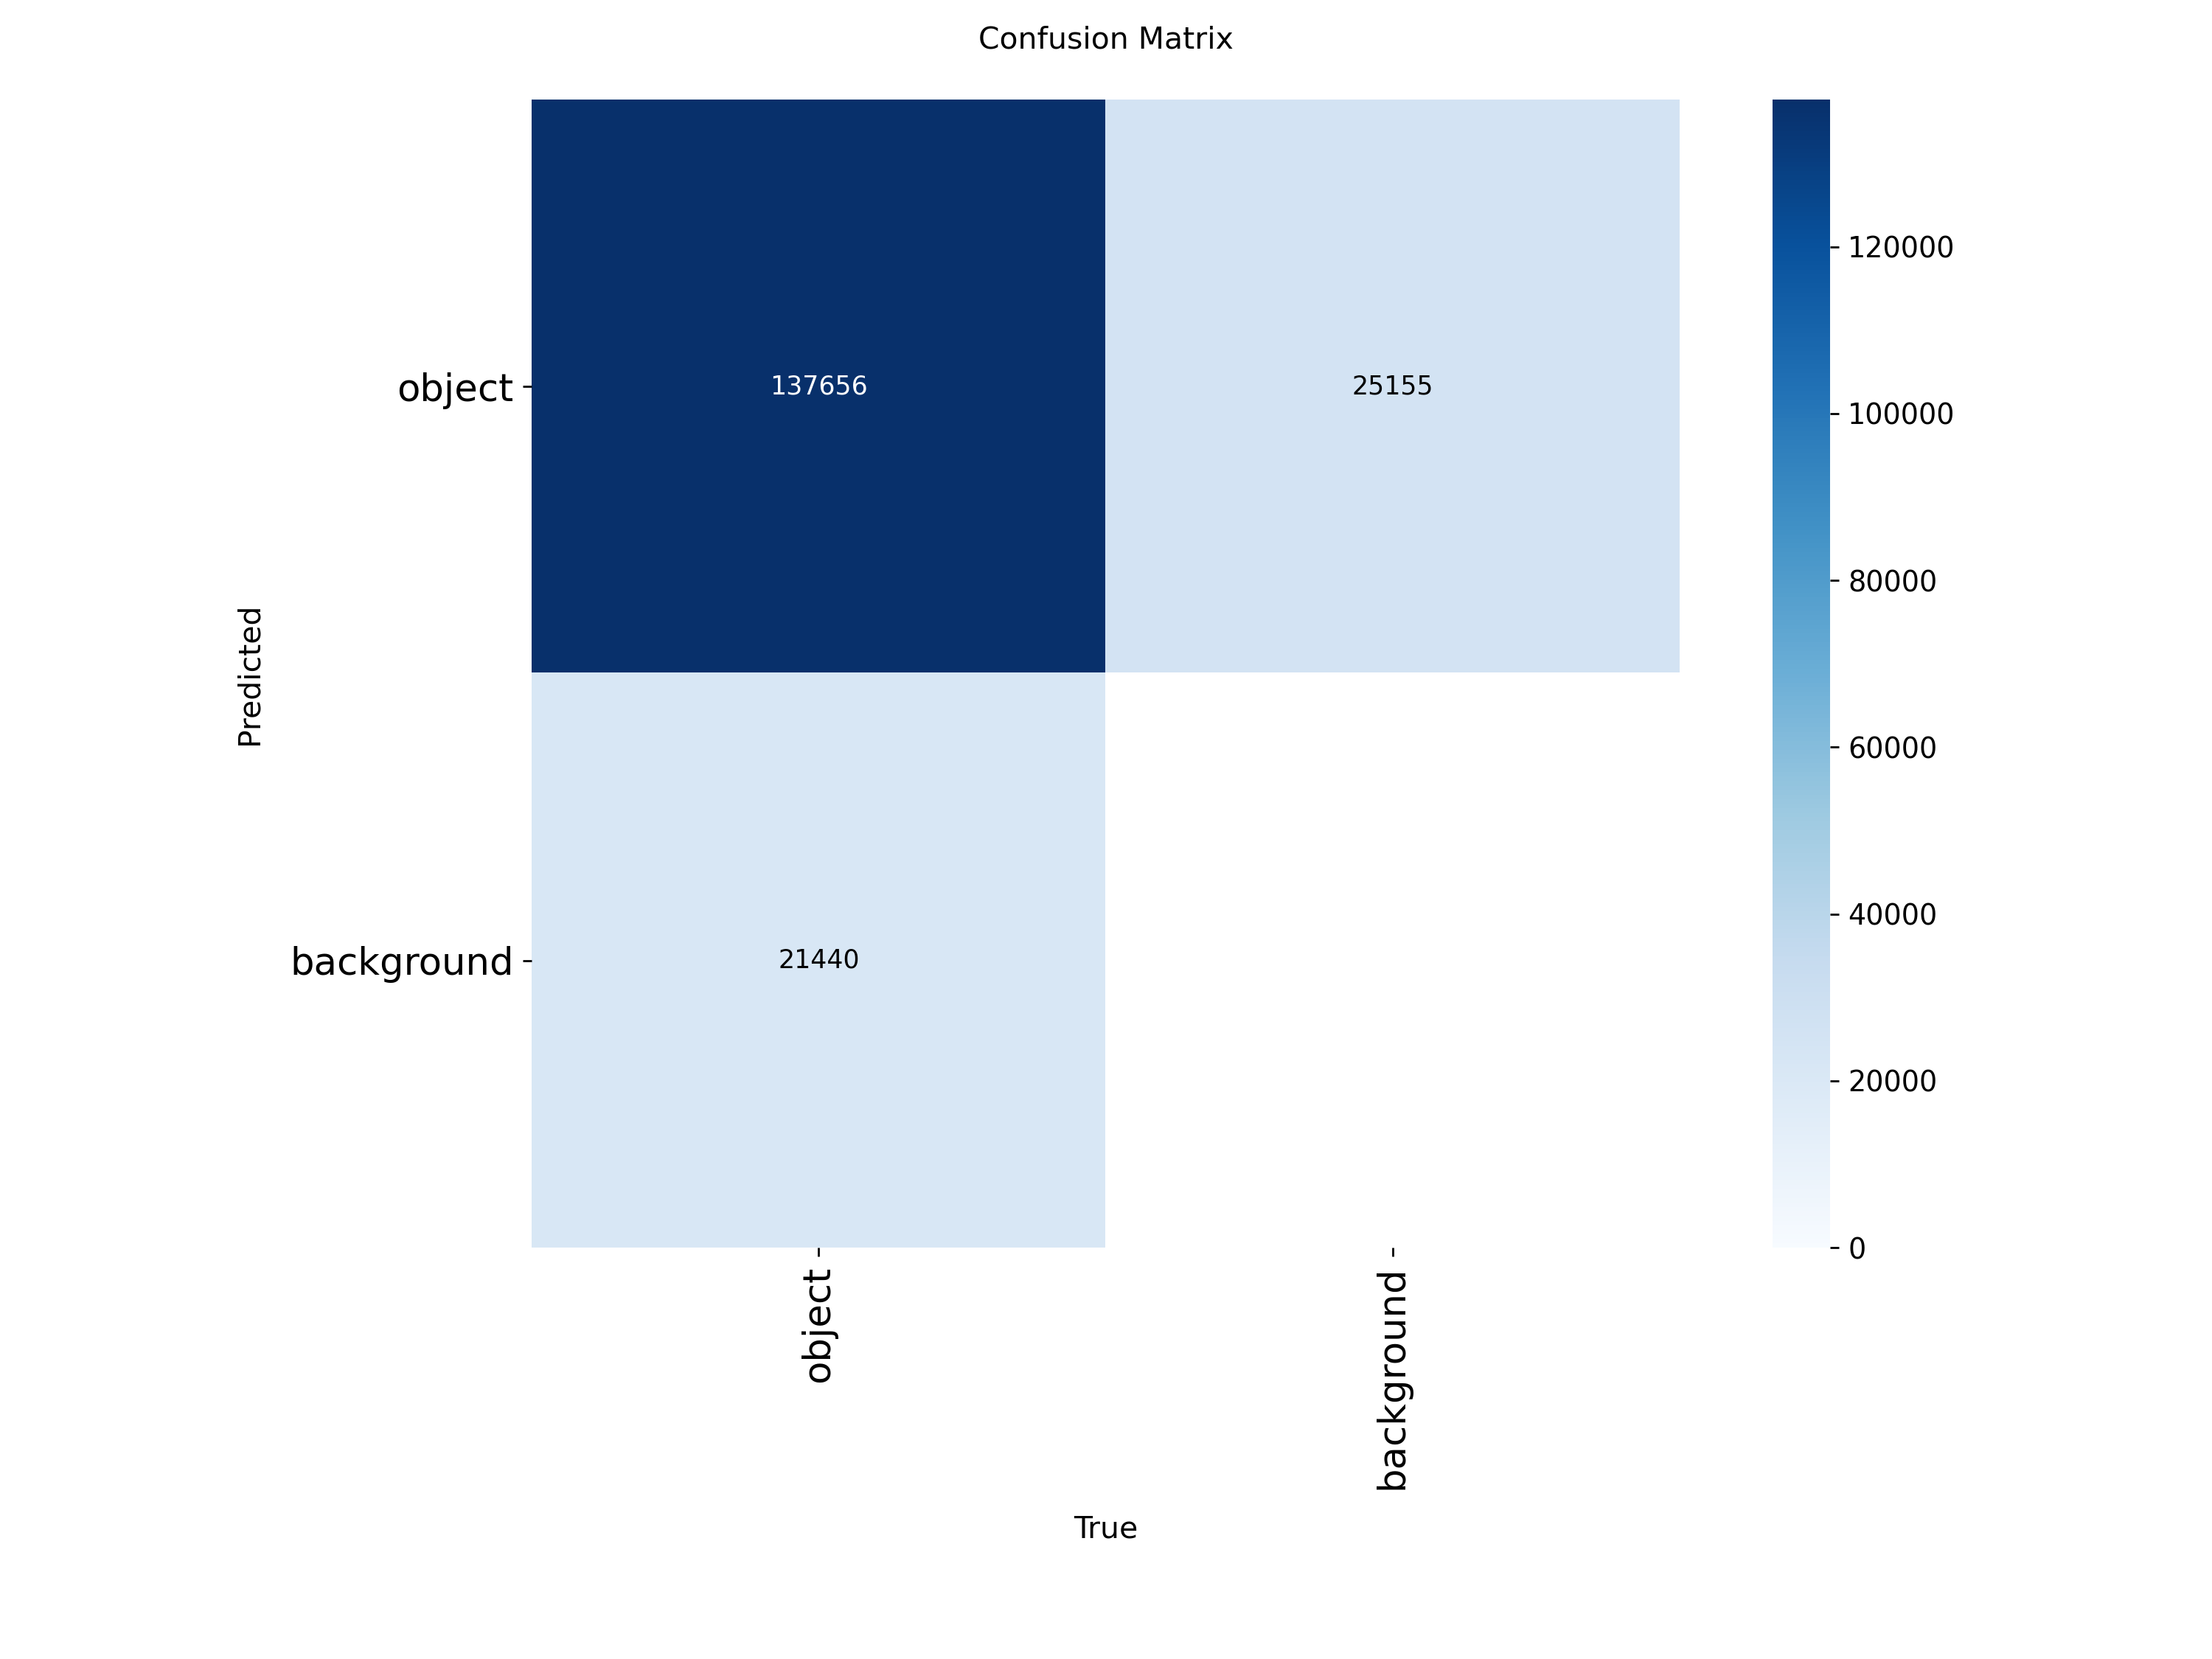

Metricas

Época final: 20
mAP50 (Detección): 0.8959
mAP50-95 (Detección): 0.5655

Entrenamiento completado
Mejor modelo guardado en: runs/detect/train/weights/best.pt


In [7]:
import os
from IPython.display import Image, display
import pandas as pd
import matplotlib.pyplot as plt

# Ruta a resultados
exp_name = 'train'
results_path = f'runs/detect/{exp_name}'

print(f"Resultados en: {results_path}\n")

# Mostrar imágenes principales
print("Visualizaciones")

imgs = {
    'Curvas de entrenamiento': 'results.png',
    'Predicciones de validación': 'val_batch0_pred.jpg',
    'Ground Truth': 'val_batch0_labels.jpg',
    'Matriz de confusión': 'confusion_matrix.png'
}

for titulo, archivo in imgs.items():
    path = f'{results_path}/{archivo}'
    if os.path.exists(path):
        print(f"\n{titulo}:")
        display(Image(filename=path, width=800))

# Métricas finales
print("Metricas")

df = pd.read_csv(f'{results_path}/results.csv')
ultima_epoca = df.iloc[-1]

print(f"\nÉpoca final: {int(ultima_epoca['epoch'])}")
print(f"mAP50 (Detección): {ultima_epoca['metrics/mAP50(B)']:.4f}")
print(f"mAP50-95 (Detección): {ultima_epoca['metrics/mAP50-95(B)']:.4f}")

print("\nEntrenamiento completado")
print(f"Mejor modelo guardado en: {results_path}/weights/best.pt")

In [5]:
# Seleccionar una imagen del conjunto de prueba
img_path = 'dataset/test/images/test_48_jpg.rf.3dc53433f9209b0124b455057222a583.jpg'

# Realizar predicción
resultados = model(img_path)

# Mostrar detecciones iniciales (sin filtrar)
print(f"Objetos detectados inicialmente: {len(resultados[0].boxes)}")

# Ver la imagen con las detecciones
resultados[0].show()


image 1/1 /home/ciabd12/Documentos/Ejercicios-Python/Mia/Practica_deteccion_objetos/dataset/test/images/test_48_jpg.rf.3dc53433f9209b0124b455057222a583.jpg: 640x480 126 objects, 48.1ms
Speed: 1.6ms preprocess, 48.1ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)
Objetos detectados inicialmente: 126


In [9]:
from collections import Counter

# 1. Definir umbral de confianza
UMBRAL_CONF = 0.4  # Solo detecciones con >40% de confianza

# 2. Extraer las cajas de la predicción
prediccion = resultados[0]
cajas_totales = prediccion.boxes

# 3. Filtrar cajas por confianza
boxes_filtradas = [box for box in cajas_totales if box.conf > UMBRAL_CONF]
print(f"Objetos reales tras filtrar (Confianza > {UMBRAL_CONF}): {len(boxes_filtradas)}")

# 4. Contar por tipo de objeto
ids_clases = [int(box.cls) for box in boxes_filtradas]
conteos = Counter(ids_clases)

# 5. Mostrar reporte
print("\n📊 REPORTE DE INVENTARIO:")
nombres_clases = model.names
for clase_id, cantidad in conteos.items():
    nombre_obj = nombres_clases[clase_id]
    print(f" -> {nombre_obj}: {cantidad} unidades")

Objetos reales tras filtrar (Confianza > 0.4): 103

📊 REPORTE DE INVENTARIO:
 -> object: 103 unidades


In [16]:
import cv2
import matplotlib.pyplot as plt

def visualizar_conteo(prediccion, boxes_filtradas, conteos, umbral):
    # 1. Filtrar cajas visualmente
    prediccion.boxes = prediccion.boxes[prediccion.boxes.conf > umbral]
    
    # 2. Generar imagen con cajas dibujadas
    img_resultado = prediccion.plot()
    
    # 5. Convertir BGR a RGB (para Matplotlib)
    img_rgb = cv2.cvtColor(img_resultado, cv2.COLOR_BGR2RGB)
    
    # 6. Mostrar imagen
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Detección con Umbral: {umbral}")
    plt.show()

# Ejecutar visualización
visualizar_conteo(resultados[0], boxes_filtradas, conteos, UMBRAL_CONF)

<Figure size 1200x800 with 1 Axes>

In [13]:
import glob
from collections import Counter

def analizar_estanteria(ruta_imagen, umbral=0.4):
    """
    Analiza una imagen y devuelve el número total de productos detectados.
    
    Args:
        ruta_imagen: Ruta a la imagen a analizar
        umbral: Umbral de confianza mínimo
    
    Returns:
        int: Número total de productos detectados
    """
    if not os.path.exists(ruta_imagen):
        print(f"❌ NO EXISTE: {ruta_imagen}")
        return 0
    
    # Realizar predicción
    resultados = model(ruta_imagen)
    prediccion = resultados[0]
    
    # Debug: mostrar cuántas cajas devuelve el modelo
    print(f"🖼️  Imagen: {os.path.basename(ruta_imagen)}")
    print(f"   - Boxes totales: {len(prediccion.boxes)}")
    
    # Filtrar por confianza de forma segura
    boxes_filtradas = [box for box in prediccion.boxes if float(box.conf) > umbral]
    print(f"   - Boxes tras filtrar (umbral={umbral}): {len(boxes_filtradas)}")
    
    # Contar por clase
    ids_clases = [int(box.cls) for box in boxes_filtradas]
    conteos = Counter(ids_clases)
    
    # Mostrar resultados por clase
    nombres = model.names
    for clase_id, cantidad in conteos.items():
        print(f"   - {nombres[clase_id]}: {cantidad} unidades")
    if not conteos:
        print("   - No se detectaron objetos con la confianza solicitada.")
    
    # Visualizar
    visualizar_conteo(prediccion, boxes_filtradas, conteos, umbral)
    
    return len(boxes_filtradas)

# Obtener imágenes de prueba (ajusta la ruta según tu estructura)
rutas_test = glob.glob('dataset/test/images/*.jpg')

print("Imágenes encontradas:", len(rutas_test))
if len(rutas_test) == 0:
    print("⚠️  No se encontraron imágenes. Intentando otras rutas...")
    alternativas = [
        'Practica_deteccion_objetos/dataset/test/images/*.jpg',
        './dataset/test/images/*.jpg',
        '/home/ciabd12/Documentos/Ejercicios-Python/Mia/Practica_deteccion_objetos/dataset/test/images/*.jpg'
    ]
    for alt in alternativas:
        rutas_test = glob.glob(alt)
        if len(rutas_test) > 0:
            print(f"✅ Imágenes encontradas en: {alt}")
            break

# Procesar las primeras 3 imágenes
print("="*60)
print("ANÁLISIS DE ESTANTERÍAS")
print("="*60)

for ruta in rutas_test[:3]:
    total = analizar_estanteria(ruta, umbral=0.4)
    print(f"✅ Procesada correctamente, total: {total}\n")

Imágenes encontradas: 518
ANÁLISIS DE ESTANTERÍAS

image 1/1 /home/ciabd12/Documentos/Ejercicios-Python/Mia/Practica_deteccion_objetos/dataset/test/images/train_5374_jpg.rf.e702323260857a35cdc3b18d91737d27.jpg: 640x480 159 objects, 6.8ms
Speed: 1.6ms preprocess, 6.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)
image 1/1 /home/ciabd12/Documentos/Ejercicios-Python/Mia/Practica_deteccion_objetos/dataset/test/images/train_5374_jpg.rf.e702323260857a35cdc3b18d91737d27.jpg: 640x480 159 objects, 6.8ms
Speed: 1.6ms preprocess, 6.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)
🖼️  Imagen: train_5374_jpg.rf.e702323260857a35cdc3b18d91737d27.jpg
   - Boxes totales: 159
   - Boxes tras filtrar (umbral=0.4): 153
   - object: 153 unidades
🖼️  Imagen: train_5374_jpg.rf.e702323260857a35cdc3b18d91737d27.jpg
   - Boxes totales: 159
   - Boxes tras filtrar (umbral=0.4): 153
   - object: 153 unidades


<Figure size 1200x800 with 1 Axes>

✅ Procesada correctamente, total: 153


image 1/1 /home/ciabd12/Documentos/Ejercicios-Python/Mia/Practica_deteccion_objetos/dataset/test/images/train_1016_jpg.rf.eae2cac563a6b60c703129a30844e113.jpg: 640x480 135 objects, 5.4ms
Speed: 1.4ms preprocess, 5.4ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)
image 1/1 /home/ciabd12/Documentos/Ejercicios-Python/Mia/Practica_deteccion_objetos/dataset/test/images/train_1016_jpg.rf.eae2cac563a6b60c703129a30844e113.jpg: 640x480 135 objects, 5.4ms
Speed: 1.4ms preprocess, 5.4ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)
🖼️  Imagen: train_1016_jpg.rf.eae2cac563a6b60c703129a30844e113.jpg
   - Boxes totales: 135
   - Boxes tras filtrar (umbral=0.4): 129
   - object: 129 unidades
🖼️  Imagen: train_1016_jpg.rf.eae2cac563a6b60c703129a30844e113.jpg
   - Boxes totales: 135
   - Boxes tras filtrar (umbral=0.4): 129
   - object: 129 unidades


<Figure size 1200x800 with 1 Axes>

✅ Procesada correctamente, total: 129


image 1/1 /home/ciabd12/Documentos/Ejercicios-Python/Mia/Practica_deteccion_objetos/dataset/test/images/train_730_jpg.rf.07f9b2e1290201f5a8cfbaadbcdd042e.jpg: 640x480 159 objects, 5.7ms
Speed: 2.2ms preprocess, 5.7ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)
image 1/1 /home/ciabd12/Documentos/Ejercicios-Python/Mia/Practica_deteccion_objetos/dataset/test/images/train_730_jpg.rf.07f9b2e1290201f5a8cfbaadbcdd042e.jpg: 640x480 159 objects, 5.7ms
Speed: 2.2ms preprocess, 5.7ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)
🖼️  Imagen: train_730_jpg.rf.07f9b2e1290201f5a8cfbaadbcdd042e.jpg
   - Boxes totales: 159
   - Boxes tras filtrar (umbral=0.4): 131
   - object: 131 unidades
🖼️  Imagen: train_730_jpg.rf.07f9b2e1290201f5a8cfbaadbcdd042e.jpg
   - Boxes totales: 159
   - Boxes tras filtrar (umbral=0.4): 131
   - object: 131 unidades


<Figure size 1200x800 with 1 Axes>

✅ Procesada correctamente, total: 131

